# Stage 10 — Validation and Context

Independent datasets, used to validate and contextualise the frozen model and **never as inputs to it**. Both were kept out of the vulnerability score from the start, to avoid the circularity that led to dropping the EPIK+rainfall framework: a score cannot be validated with the data that built it.

- **CFEV Groundwater Dependent Ecosystems (springs)** — the only independent hydrological check available: do known springs/GDEs sit in the more connected/susceptible parts of the karst?
- **CFEV Karst conservation value** — not validation (it measures something different from vulnerability), but context: where does land-use pressure risk coincide with conservation significance?

**Design of the GDE test:**
1. The null distribution is built from **karst cells only**. A null built from the whole raster would mostly detect that karst scores higher than non-karst.
2. GDE points are compared against **intrinsic vulnerability** (susceptibility × connectivity), not final risk. Land-use pressure has no plausible causal link to where a spring occurs.
3. GDE points are heavily clustered (all 37 Mole Creek points are nearest to one named system; 112 statewide points reduce to ~25 systems), so replication is at the **system level**, not the point level.
4. Some statewide spring types (warm, mound) have no obvious relationship to karst connectivity.

The result is in 10.1 below.

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from rasterio.transform import rowcol
import matplotlib.pyplot as plt
import sys

sys.path.insert(0, str(Path("..") / "src"))
from karst import add_karst_susceptibility, add_connectivity, rasterize_max

data = Path(os.environ.get("AT3_DATA_DIR", "data"))
inpath = data / "Input_data"
outpath = data / "Output_data"

def sample_raster_array(arr, transform, points_gdf):
    """Sample a numpy array (already masked to NaN where invalid) at point locations."""
    vals = []
    for p in points_gdf.geometry:
        r, c = rowcol(transform, p.x, p.y)
        vals.append(arr[r, c] if 0 <= r < arr.shape[0] and 0 <= c < arr.shape[1] else np.nan)
    return np.array(vals)

def permutation_percentile(valid_vals, actual_mean, n_sample, n_perm=10000, seed=42):
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(valid_vals), size=(n_perm, n_sample))
    sample_means = valid_vals[idx].mean(axis=1)
    pct = (sample_means < actual_mean).mean() * 100
    return pct, sample_means

## 10.1 GDE springs — hydrological plausibility check

115 statewide GDE points (springs, subsurface streams) from CFEV.
**Never used to build the connectivity score** — `KPROXCATCH`,
exposure type, and DEM flow accumulation were the inputs; this is the
first time these points have touched the model at all.

Tested against **intrinsic vulnerability** (susceptibility × connectivity,
before land-use pressure is applied) rather than final risk, and against
a null built from **karst cells only** — so this asks "do GDEs sit in the
more connected/susceptible parts of the karst?", not the much easier
question "is karst riskier than non-karst?" (true by construction, and
uninformative about the connectivity score specifically).

In [2]:
gde = gpd.read_file(inpath / "LIST_CFEV_GROUNDWATER_STATEWIDE/list_cfev_groundwater_statewide.shp").to_crs("EPSG:7855")
print("GDE types statewide:")
print(gde["GDE_TYPE"].value_counts())

mc_boundary = gpd.read_file(outpath / "mole_creek_bounding_box_EPSG7855.gpkg")
gde_mc = gpd.clip(gde, mc_boundary)
print(f"\nGDE points within Mole Creek: {len(gde_mc)} of {len(gde)} statewide")

GDE types statewide:
GDE_TYPE
Tufa-depositing spring    54
Cold spring               23
Subsurface stream         23
Warm spring                8
Mound spring               7
Name: count, dtype: int64

GDE points within Mole Creek: 37 of 115 statewide


### Mole Creek: descriptive only, not a permutation test

Each point's nearest named karst system shows that Mole Creek's 37 GDE points are not independent samples: **all 37 are nearest to the single system "Mole Creek."** A permutation test treats each point as an independent draw, so with one effective system a p-value from n = 37 would overstate the evidence by roughly 37-fold. The comparison is descriptive: GDE-point mean, karst-only mean and whole-area mean, with no p-value.

In [3]:
with rasterio.open(outpath / "karst_intensity_mc_EPSG7855.tif") as src:
    intensity = src.read(1).astype(float); mc_transform = src.transform
with rasterio.open(outpath / "connectivity_atlas_mc_EPSG7855.tif") as src:
    connectivity = src.read(1).astype(float)
with rasterio.open(outpath / "dem_mc_EPSG7855.tif") as src:
    dem = src.read(1); dem_nodata = src.nodata
valid_mc = dem != dem_nodata
karst_mc_cells = intensity > 0
intrinsic_mc = np.where(valid_mc, (intensity / 4.0) * (connectivity / 3.0), np.nan)

karst_mc_atlas = gpd.read_file(outpath / "karst_mc_connectivity_EPSG7855.gpkg")
karst_mc_atlas = karst_mc_atlas[karst_mc_atlas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
gde_mc_nearest = gpd.sjoin_nearest(gde_mc, karst_mc_atlas[["KNAME", "geometry"]], how="left")
print("Mole Creek GDE points by nearest named system:")
print(gde_mc_nearest["KNAME"].value_counts())

intrinsic_at_gde_mc = sample_raster_array(intrinsic_mc, mc_transform, gde_mc)
print(f"\nMean intrinsic vulnerability at GDE points:   {np.nanmean(intrinsic_at_gde_mc):.4f}  (n={np.sum(~np.isnan(intrinsic_at_gde_mc))})")
print(f"Mean intrinsic vulnerability, karst cells only: {np.nanmean(intrinsic_mc[karst_mc_cells & valid_mc]):.4f}")
print(f"Mean intrinsic vulnerability, ALL valid cells:  {np.nanmean(intrinsic_mc[valid_mc]):.4f}")

Mole Creek GDE points by nearest named system:
KNAME
Mole Creek    37
Name: count, dtype: int64

Mean intrinsic vulnerability at GDE points:   0.5676  (n=37)
Mean intrinsic vulnerability, karst cells only: 0.6886
Mean intrinsic vulnerability, ALL valid cells:  0.1554


**Result: GDE points sit inside karst (far above the whole-area mean, as
expected), but *within* karst they are if anything slightly below the
karst-wide average, not above it.** This single-system result can't carry
statistical weight on its own (n=1 effective system), but it previews the
statewide finding below, and it does not support a claim that Mole
Creek's springs specifically favour the model's highest-connectivity
cells.

### Statewide: system-level test (not point-level)

The 112 statewide GDE points cluster into only **~25 distinct named karst systems** by nearest neighbour. The test is built around systems: one intrinsic-vulnerability value per system (the mean over its GDE points), compared against a null of 10,000 random same-size samples of karst-only cells.

In [4]:
tasmania = gpd.read_file(outpath / "tasmania_bounding_box_EPSG7855.gpkg")
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    tas_shape = (src.height, src.width); tas_transform = src.transform; tas_nodata = src.nodata
    land_masked, _ = mask(src, tasmania.geometry, crop=False, nodata=tas_nodata)
tas_valid = land_masked[0] != tas_nodata

karst_tas = gpd.read_file(inpath / "KarstAtlas/Karst_Ver_3_1/Karst_Atlas_v3_1.shp").to_crs("EPSG:7855")
karst_tas = karst_tas[karst_tas.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
add_karst_susceptibility(karst_tas)
add_connectivity(karst_tas)
tas_intensity_raster = rasterize_max(karst_tas, "karst_intensity", tas_shape, tas_transform)
tas_connectivity_raster = rasterize_max(karst_tas, "connectivity", tas_shape, tas_transform)
tas_karst_cells = tas_intensity_raster > 0
tas_intrinsic = np.where(tas_valid, (tas_intensity_raster.astype(float) / 4.0) * (tas_connectivity_raster.astype(float) / 3.0), np.nan)

gde_tas = gpd.clip(gde, tasmania)
gde_tas_joined = gpd.sjoin_nearest(gde_tas, karst_tas[["KNAME", "geometry"]], how="left")
print(f"Statewide GDE points cluster into {gde_tas_joined['KNAME'].nunique()} distinct named systems (of {len(gde_tas)} points)")
print(gde_tas_joined["KNAME"].value_counts().head(8))

core_types = ["Tufa-depositing spring", "Cold spring", "Subsurface stream"]
print(f"\nSpring types excluded as having no plausible link to karst connectivity (warm/mound springs are thermal/structural features): "
      f"{(~gde_tas['GDE_TYPE'].isin(core_types)).sum()} of {len(gde_tas)} points")

system_means = gde_tas_joined.groupby("KNAME").apply(
    lambda g: np.nanmean(sample_raster_array(tas_intrinsic, tas_transform, g))
).dropna()
n_systems = len(system_means)
actual_system_mean = system_means.mean()

karst_only_vals_tas = tas_intrinsic[tas_karst_cells & tas_valid]
pct_sys, null_sys = permutation_percentile(karst_only_vals_tas, actual_system_mean, n_systems)

print(f"\n{n_systems} systems with a valid raster value, mean-of-system-means = {actual_system_mean:.4f}")
print(f"Null (10,000 samples of {n_systems} karst-only cells): mean={null_sys.mean():.4f}, 95th pct={np.percentile(null_sys, 95):.4f}")
print(f"Actual system-mean falls at the {pct_sys:.2f}th percentile of the karst-only null")

Statewide GDE points cluster into 26 distinct named systems (of 112 points)
KNAME
Mole Creek                                  37
Lune Plains (North Lune, Mesa-Gleichenia    10
Loongana                                     6
Junee - Florentine                           5
Deep Glen                                    3
(too) many                                   2
Gunns Plains                                 2
Irishtown - Sedgy Creek (1)                  2
Name: count, dtype: int64

Spring types excluded as having no plausible link to karst connectivity (warm/mound springs are thermal/structural features): 15 of 112 points

25 systems with a valid raster value, mean-of-system-means = 0.4436
Null (10,000 samples of 25 karst-only cells): mean=0.5909, 95th pct=0.6700
Actual system-mean falls at the 0.08th percentile of the karst-only null


/var/folders/8l/2f4_sjbs057dtvrflrlb5sj40000gn/T/ipykernel_34385/1582592182.py:26: RuntimeWarning: Mean of empty slice
  lambda g: np.nanmean(sample_raster_array(tas_intrinsic, tas_transform, g))


**Result: no evidence that GDEs preferentially occupy the higher-connectivity parts of the karst.** The statewide GDE systems' mean intrinsic vulnerability (≈0.44) falls at roughly the **0.1st percentile** of the karst-only null, *below* essentially all 10,000 random same-size samples, not above them. With only ~25 systems, this is too small a sample to call a confident finding in either direction.

For comparison, an unrestricted test (GDE points against the whole raster, all 112 points treated as independent) gives a much larger apparent enrichment (11.5× background risk, p < 0.0001). That figure mostly reflects karst scoring higher than non-karst, which the model guarantees by construction. It does not validate the connectivity component.

**Limitation:** CFEV's GDE locations were likely mapped partly from existing karst and geological knowledge, the same knowledge that feeds the susceptibility and connectivity layers. Even the restricted test is therefore independent-ish, not a clean external validation.

## 10.2 CFEV conservation value × risk priority matrix

Not validation — CFEV conservation value measures ecological/geological
significance, a different thing from land-use pressure vulnerability.
Combining them identifies **where pressure and significance coincide**,
which is the actionable output: a location with high risk but low
conservation value is a different management problem than one with
both high risk and high conservation value.

CFEV Karst uses different polygon boundaries from the Karst Atlas used
throughout this project (confirmed earlier: "Mole Creek" splits into
"Mole Creek 1-4" in CFEV) — joined here by spatial overlay, not by
name.

In [5]:
cfev = gpd.read_file(inpath / "LIST_CFEV_KARST_STATEWIDE/list_cfev_karst_statewide.shp").to_crs("EPSG:7855")
cfev = cfev[cfev.geom_type.isin(["Polygon", "MultiPolygon"])].copy()
print(f"CFEV Karst polygons statewide: {len(cfev)}")
print(cfev["KT_ICV"].value_counts())  # Integrated Conservation Value: M/H/VH

CFEV Karst polygons statewide: 334
KT_ICV
M     186
H     128
VH     20
Name: count, dtype: int64


In [6]:
rows = []
with rasterio.open(outpath / "risk_tas_2020_100m_EPSG7855.tif") as src:
    for _, row in cfev.iterrows():
        out_image, _ = mask(src, [row.geometry], crop=True, nodata=tas_nodata)
        v = out_image[0]
        v = v[v != tas_nodata]
        rows.append({"KT_NAME": row["KT_NAME"], "KT_ICV": row["KT_ICV"],
                     "mean_risk": v.mean() if len(v) else np.nan, "n_pixels": len(v)})

cfev_risk = pd.DataFrame(rows)
print(f"CFEV polygons with a valid risk value: {cfev_risk['mean_risk'].notna().sum()} / {len(cfev_risk)}")
print(f"Polygons with fewer than 5 valid pixels: {(cfev_risk['n_pixels'] < 5).sum()}; "
      f"fewer than 10: {(cfev_risk['n_pixels'] < 10).sum()} -- these mean_risk values are unreliable (one or two 100m pixels).")
print(cfev_risk.groupby("KT_ICV")["mean_risk"].agg(["mean", "count"]))

CFEV polygons with a valid risk value: 328 / 334
Polygons with fewer than 5 valid pixels: 30; fewer than 10: 46 -- these mean_risk values are unreliable (one or two 100m pixels).
            mean  count
KT_ICV                 
H       0.239417    125
M       0.217692    183
VH      0.277184     20


**The conservation-value gradient is nearly flat** (0.218 Medium → 0.239 High → 0.277 Very High): the ordering is in the expected direction, but conservation value is not a strong predictor of modelled risk by this measure.

Risk class x Conservation value matrix (polygon counts):
KT_ICV          M   H  VH
risk_class               
Low risk       62  45   3
Moderate risk  67  37   5
High risk      54  43  12

Note: 'risk_class' is a tertile split of this exact set of polygons, so each class contains ~1/3 of all 328 polygons *by construction*, regardless of whether there's any real risk signal. It's a ranking device for the priority list below, not itself a finding.


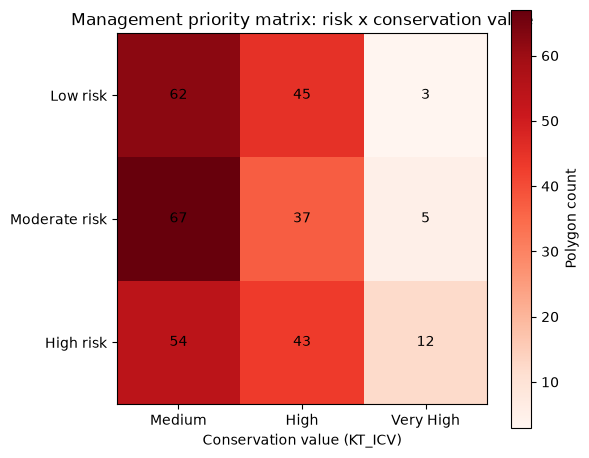

In [7]:
valid_cfev = cfev_risk.dropna(subset=["mean_risk"]).copy()
tertiles = valid_cfev["mean_risk"].quantile([1/3, 2/3]).values

def risk_class(r):
    if r <= tertiles[0]:
        return "Low risk"
    elif r <= tertiles[1]:
        return "Moderate risk"
    return "High risk"

valid_cfev["risk_class"] = valid_cfev["mean_risk"].apply(risk_class)
matrix = pd.crosstab(valid_cfev["risk_class"], valid_cfev["KT_ICV"])
matrix = matrix.reindex(index=["Low risk", "Moderate risk", "High risk"], columns=["M", "H", "VH"])
print("Risk class x Conservation value matrix (polygon counts):")
print(matrix)
print("\nNote: 'risk_class' is a tertile split of this exact set of polygons, so each class contains "
      "~1/3 of all 328 polygons *by construction*, regardless of whether there's any real risk signal. "
      "It's a ranking device for the priority list below, not itself a finding.")

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(matrix.values, cmap="Reds")
ax.set_xticks(range(3)); ax.set_xticklabels(["Medium", "High", "Very High"])
ax.set_yticks(range(3)); ax.set_yticklabels(["Low risk", "Moderate risk", "High risk"])
for i in range(3):
    for j in range(3):
        ax.text(j, i, matrix.values[i, j], ha="center", va="center")
ax.set_xlabel("Conservation value (KT_ICV)")
ax.set_title("Management priority matrix: risk x conservation value")
plt.colorbar(im, label="Polygon count")
plt.tight_layout()
plt.show()

### Priority zones, with pixel counts and a minimum-size filter

Some of the top-ranked entries in an unfiltered list were polygons with only a handful of valid 100 m pixels (down to 2), so their `mean_risk` lands on round fractions (e.g. exactly 0.75 or 0.50) from averaging 4 or 2 pixels. The ranking therefore shows `n_pixels` and requires a minimum of 10 valid pixels (0.1 km²).

In [8]:
priority_all = valid_cfev[(valid_cfev["risk_class"] == "High risk") & (valid_cfev["KT_ICV"].isin(["H", "VH"]))]
priority_all = priority_all.sort_values("mean_risk", ascending=False)

priority_filtered = priority_all[priority_all["n_pixels"] >= 10]

print(f"Unfiltered: {len(priority_all)} of {len(valid_cfev)} polygons qualify as 'high risk + high/VH conservation value' "
      "-- but recall the tertile split guarantees roughly 1/3 of all polygons are 'High risk' regardless of signal, "
      "so this count is not itself evidence of anything; it's a ranking device.")
print(f"After requiring >= 10 valid pixels: {len(priority_filtered)} polygons remain "
      f"({len(priority_all) - len(priority_filtered)} dropped for being too small to trust)")

print("\nTop 15, size-filtered:")
print(priority_filtered[["KT_NAME", "mean_risk", "KT_ICV", "n_pixels"]].head(15).to_string(index=False))

priority_filtered.to_csv(outpath / "stage10_priority_zones.csv", index=False)

mole_creek_rows = cfev_risk[cfev_risk["KT_NAME"].str.contains("Mole Creek", na=False)]
print("\nMole Creek's own CFEV entries, for context:")
print(mole_creek_rows.to_string(index=False))

Unfiltered: 55 of 328 polygons qualify as 'high risk + high/VH conservation value' -- but recall the tertile split guarantees roughly 1/3 of all polygons are 'High risk' regardless of signal, so this count is not itself evidence of anything; it's a ranking device.
After requiring >= 10 valid pixels: 51 polygons remain (4 dropped for being too small to trust)

Top 15, size-filtered:
                         KT_NAME  mean_risk KT_ICV  n_pixels
              Emita - Memana (2)   0.694615      H      7499
                    Grim-Trefoil   0.625000      H        11
                      Port Hills   0.571429      H        57
                Mt Stanley Creek   0.552826      H        14
                Fairview (Redpa)   0.513328      H       303
                  Whistler-Porky   0.473140      H      6074
                           Ranga   0.458066      H      1504
           City of Melbourne Bay   0.455555      H        14
                         Phoques   0.453579      H      5811
     

**Result:** after filtering out undersized polygons, a double-digit number of named systems statewide combine high modelled risk with high/very-high conservation value. This is a ranked, actionable list distinct from the risk map alone. The exact count depends on the tertile cut and the pixel-count threshold, so treat it as a list to follow up on, not a precise statistic. Mole Creek's own CFEV entries (1-4) sit at VH conservation value with moderate risk, consistent with but not identical to the Karst-Atlas-based "Mole Creek" result from Stages 6-8, since CFEV uses different polygon boundaries.

## Not done here

TGD (Tasmanian Geoconservation Database) and KID (Karst Index Database) cross-checks were scoped as optional, time-permitting (scope doc, Stage 10). They were not built.

## Stage 10 summary

- **GDE validation:** with a karst-only null, intrinsic vulnerability rather than risk, and system-level replication, the test does not support the claim that springs favour higher-connectivity karst. Mole Creek has one effective system and cannot carry a p-value. Statewide, GDE systems fall below the median of the karst-only null.
- **Independence:** CFEV GDE points are plausibly not fully independent of the karst and geology data used to build the model.
- **Conservation value:** the gradient is in the expected direction but nearly flat (0.218 / 0.239 / 0.277).
- **Priority zones:** a useful ranking tool, not a precise statistic. The count depends on a tertile split (which puts ~1/3 of polygons in "high risk") and on the minimum pixel-count filter.

## Stage 10 outputs

- `stage10_priority_zones.csv` — size-filtered statewide high-risk/high-conservation-value systems, with pixel counts

**Next:** write the Jupyter Book chapters (`introduction.md`, `methods.md`, `results.md`, `discussion.md`, `conclusion.md`, `reference.md`).